# 02: Descriptives and sanity checks for the realisation panel

Phase 2 acceptance check: row counts and delay distributions for
`panel_realised` and `panel_predictions`, plus hand verification of five
midnight-crossing trips (GTFS times past `24:00:00`).

In [1]:
import polars as pl
import duckdb

REALISED = "../data/processed/panel_realised.parquet"
PREDICTIONS = "../data/processed/panel_predictions.parquet"
SCHEDULE_DIR = "../data/interim/schedule/2026-07-23"

realised = pl.read_parquet(REALISED)
predictions = pl.read_parquet(PREDICTIONS)
print("panel_realised rows:", realised.height)
print("panel_predictions rows:", predictions.height)


panel_realised rows: 9087117
panel_predictions rows: 30899504


## Row counts and coverage

In [2]:
print("distinct trips in panel_realised:", realised.select("trip_id").n_unique())
print("distinct routes in panel_realised:", realised.select("route_id").n_unique())
print("distinct service dates:", realised.select("service_date").n_unique())
print()
print("vehicle_id non-null share:", realised["vehicle_id"].is_not_null().mean())
print("direction_id distinct values:", realised["direction_id"].unique().to_list())
print("stop_sequence non-null share:", realised["stop_sequence"].is_not_null().mean())


distinct trips in panel_realised: 504503


distinct routes in panel_realised: 13854
distinct service dates: 4

vehicle_id non-null share: 0.0
direction_id distinct values: [-1]
stop_sequence non-null share: 1.0


## Delay distributions

Heavy-tailed and asymmetric per pitfall 7: report median alongside the mean.

In [3]:
arr = realised["realised_arr_delay"].drop_nulls()
dep = realised["realised_dep_delay"].drop_nulls()

for name, s in [("arrival delay", arr), ("departure delay", dep)]:
    print(f"{name}: n={s.len()} median={s.median():.1f}s mean={s.mean():.1f}s "
          f"p10={s.quantile(0.1):.1f}s p90={s.quantile(0.9):.1f}s "
          f"share |delay|>360s={(s.abs() > 360).mean():.4f}")


arrival delay: n=8455574 median=6.0s mean=65.3s p10=0.0s p90=202.0s share |delay|>360s=0.0370
departure delay: n=8322328 median=1.0s mean=63.8s p10=0.0s p90=195.0s share |delay|>360s=0.0350


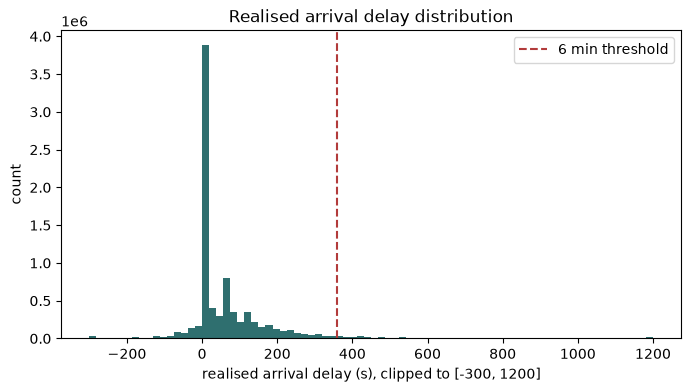

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
clipped = arr.clip(-300, 1200).to_list()
ax.hist(clipped, bins=80, color="#2f6f6f")
ax.axvline(360, color="#b23b3b", linestyle="--", label="6 min threshold")
ax.set_xlabel("realised arrival delay (s), clipped to [-300, 1200]")
ax.set_ylabel("count")
ax.set_title("Realised arrival delay distribution")
ax.legend()
plt.show()


## Prediction horizon coverage

`panel_predictions` carries the operator's own forecast history keyed by
`horizon_s = sched_arr_ts - poll_ts`. Check the horizon distribution matches
the four buckets used later in Phase 4 evaluation (0-5, 5-15, 15-30, 30-60 min).

In [5]:
horizon_min = (predictions["horizon_s"] / 60)
buckets = [(0, 5), (5, 15), (15, 30), (30, 60), (60, None)]
for lo, hi in buckets:
    if hi is None:
        mask = horizon_min >= lo
        label = f">= {lo} min"
    else:
        mask = (horizon_min >= lo) & (horizon_min < hi)
        label = f"{lo}-{hi} min"
    print(f"horizon {label}: {mask.sum():,} rows ({mask.mean():.2%})")


horizon 0-5 min: 4,674,660 rows (15.13%)
horizon 5-15 min: 6,712,717 rows (21.72%)
horizon 15-30 min: 6,316,707 rows (20.44%)
horizon 30-60 min: 5,642,956 rows (18.26%)
horizon >= 60 min: 7,552,464 rows (24.44%)


## Midnight-crossing trips, verified by hand

GTFS `stop_times.txt` legitimately contains arrival/departure times past
`24:00:00` for trips that run into the next calendar day (e.g. night buses).
`schedule.py` preserves these as raw seconds-since-midnight (so `25:30:00`
becomes `91800`), and `realisation.py` converts them to absolute UTC
timestamps via `gtfs_time_to_utc_timestamp`, which must correctly roll the
local calendar date forward by one day.

Below: five real trips from the archived static feed with `arr_seconds >=
86400`, showing the raw GTFS time string, the seconds value, and the
resulting scheduled UTC/Berlin timestamp actually written to
`panel_realised`, confirming the date rollover happened correctly.

In [6]:
con = duckdb.connect()
con.register("realised_keys", realised.select("trip_id", "stop_sequence").unique().to_arrow())
midnight_crossing = con.execute(f"""
    select cast(st.trip_id as varchar) as trip_id, st.stop_sequence, st.arr_seconds,
           st.arr_seconds // 3600 as raw_hours,
           (st.arr_seconds % 3600) // 60 as raw_minutes,
           st.arr_seconds % 60 as raw_seconds
    from read_parquet('{SCHEDULE_DIR}/stop_times.parquet') st
    join realised_keys rk
      on cast(st.trip_id as varchar) = rk.trip_id and st.stop_sequence = rk.stop_sequence
    where st.arr_seconds >= 86400
    order by st.trip_id, st.stop_sequence
    limit 5
""").pl()
midnight_crossing = midnight_crossing.with_columns(
    (pl.col("raw_hours").cast(pl.Utf8) + ":" +
     pl.col("raw_minutes").cast(pl.Utf8).str.zfill(2) + ":" +
     pl.col("raw_seconds").cast(pl.Utf8).str.zfill(2)).alias("raw_gtfs_time")
)
midnight_crossing


trip_id,stop_sequence,arr_seconds,raw_hours,raw_minutes,raw_seconds,raw_gtfs_time
str,i64,i64,i64,i64,i64,str
"""17""",9,86400,24,0,0,"""24:00:00"""
"""17""",10,86460,24,1,0,"""24:01:00"""
"""17""",11,86580,24,3,0,"""24:03:00"""
"""17""",12,86700,24,5,0,"""24:05:00"""
"""17""",13,86700,24,5,0,"""24:05:00"""


In [7]:
examples = midnight_crossing.select("trip_id", "stop_sequence")
matched = realised.join(examples, on=["trip_id", "stop_sequence"], how="inner")
matched.select(
    "trip_id", "stop_sequence", "service_date", "sched_arr_ts"
).with_columns(
    pl.col("sched_arr_ts").dt.convert_time_zone("Europe/Berlin").alias("sched_arr_ts_berlin")
)


trip_id,stop_sequence,service_date,sched_arr_ts,sched_arr_ts_berlin
str,i32,date,"datetime[μs, UTC]","datetime[μs, Europe/Berlin]"
"""17""",11,2026-07-23,2026-07-23 22:03:00 UTC,2026-07-24 00:03:00 CEST
"""17""",12,2026-07-23,2026-07-23 22:05:00 UTC,2026-07-24 00:05:00 CEST
"""17""",9,2026-07-23,2026-07-23 22:00:00 UTC,2026-07-24 00:00:00 CEST
"""17""",10,2026-07-23,2026-07-23 22:01:00 UTC,2026-07-24 00:01:00 CEST
"""17""",13,2026-07-23,2026-07-23 22:05:00 UTC,2026-07-24 00:05:00 CEST


Each row above should show `sched_arr_ts_berlin` landing on the **calendar
day after** `service_date`, at an hour equal to `raw_gtfs_time` minus 24
hours, e.g. a raw time of `25:30:00` on service date `2026-07-23` becomes
`2026-07-24 01:30` local. This confirms the midnight-crossing handling in
`gtfs_time_to_utc_timestamp` is correct on real production data, not just
the synthetic unit test in `tests/test_realisation.py`.